# State of Data Brazil 2024
Análise exploratória da pesquisa anual sobre o mercado de dados no Brasil.  
Fonte: [State of Data Brazil 2024](https://stateofdata.com.br)
---

## 1. Imports e Configuração

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo global dos gráficos
COR_PRINCIPAL = '#4F8EF7'
COR_DESTAQUE  = '#F7874F'
COR_AMARELO   = '#F7C44F'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
})

## 2. Carregamento dos Dados

O dataset bruto tem mais de 300 colunas. Selecionei apenas as relevantes para esta análise:  
perfil acadêmico, localização, cargo, senioridade, salário e stack tecnológica.

In [5]:
RAW_PATH = Path('../data/final_dataset _state_of_data 2024_df_survey_2024.csv')

df = pd.read_csv(RAW_PATH)
print(f"Registros: {len(df):,}")
print(f"Colunas:   {len(df.columns)}")

Registros: 5,217
Colunas:   403


## 3. Preparação dos Dados

### 3.1 Seleção de colunas e filtro geográfico

In [6]:
COLUNAS = {
    # Perfil
    "1.l_nivel_de_ensino":                                    "nivel_de_ensino",
    "1.m_área_de_formação":                                   "formacao",
    # Localização
    "1.i_estado_onde_mora":                                   "estado",
    "1.i.2_regiao_onde_mora":                                 "regiao",
    # Profissional
    "2.f_cargo_atual":                                        "cargo",
    "2.g_nivel":                                              "nivel",
    "2.h_faixa_salarial":                                     "salario",
    "2.i_tempo_de_experiencia_em_dados":                      "exp_dados",
    "2.j_tempo_de_experiencia_em_ti":                         "exp_ti",
    "4.a_funcao_de_atuacao":                                  "funcao",
    "4.a.1_atuacao_em_dados":                                 "atuacao_dados",
    # Stack
    "4.b.1_Dados relacionais (estruturados em bancos SQL)":   "dados_relacionais",
    "4.b.2_Dados armazenados em bancos NoSQL":                "bancos_nosql",
    "4.b.7_Planilhas":                                        "planilhas",
    # Linguagens
    "4.d.1_SQL":                                              "usa_sql",
    "4.d.2_R":                                                "usa_r",
    "4.d.3_Python":                                           "usa_python",
    # Cloud
    "4.h.1_Amazon Web Services (AWS)":                        "aws",
    "4.h.2_Google Cloud (GCP)":                               "gcp",
    "4.h.3_Azure (Microsoft)":                                "azure",
    # BI
    "4.j.1_Microsoft PowerBI":                                "usa_powerbi",
    "4.j.3_Tableau":                                          "tableau",
    # Filtro geográfico (removida após uso)
    "1.g_vive_no_brasil":                                     "_vive_no_brasil",
}

df = (
    df[list(COLUNAS.keys())]
    .rename(columns=COLUNAS)
    .query("_vive_no_brasil == True")
    .drop(columns=["_vive_no_brasil"])
    .reset_index(drop=True)
)

print(f"Registros após filtro Brasil: {len(df):,}")

Registros após filtro Brasil: 5,078


### 3.2 Tratamento de valores ausentes

In [9]:
# Colunas binárias de ferramentas — ausente significa "não usa"
COLS_BINARIAS = ["usa_sql", "usa_r", "usa_python", "aws", "gcp", "azure", "usa_powerbi", "tableau"]
df[COLS_BINARIAS] = df[COLS_BINARIAS].fillna(0)

# Colunas categóricas — manti os ausentes como "Não informado" para rastrear a proporção
COLS_CATEGORICAS = ["cargo", "nivel", "salario", "regiao", "formacao", "funcao", "exp_dados", "exp_ti",
                    "dados_relacionais", "bancos_nosql", "planilhas"]
df[COLS_CATEGORICAS] = df[COLS_CATEGORICAS].fillna("Não informado")

# Visão geral dos ausentes remanescentes
ausentes = df.isnull().sum()
print(ausentes[ausentes > 0] if ausentes.any() else "Nenhum valor nulo restante.")
df.info()

Nenhum valor nulo restante.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078 entries, 0 to 5077
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nivel_de_ensino    5078 non-null   object 
 1   formacao           5078 non-null   object 
 2   estado             5078 non-null   object 
 3   regiao             5078 non-null   object 
 4   cargo              5078 non-null   object 
 5   nivel              5078 non-null   object 
 6   salario            5078 non-null   object 
 7   exp_dados          5078 non-null   object 
 8   exp_ti             5078 non-null   object 
 9   funcao             5078 non-null   object 
 10  atuacao_dados      5078 non-null   object 
 11  dados_relacionais  5078 non-null   object 
 12  bancos_nosql       5078 non-null   object 
 13  planilhas          5078 non-null   object 
 14  usa_sql            5078 non-null   float64
 15  usa_r              5078 non-null   float64
 

> **Nota sobre "Não informado":** cerca de 27% dos respondentes não preencheram cargo e nível.  
> Optei por manter esses registros no dataset completo e filtrá-los pontualmente em cada análise,  
> evitando descartar dados válidos em outras colunas.

### 3.3 Conversão de faixas salariais para valor numérico

In [10]:
# Cada faixa é representada pelo ponto médio do intervalo.
# Para a faixa aberta superior (> R$40k), usamos R$45k como estimativa conservadora.
SALARIO_MAP = {
    'Menos de R$ 1.000/mês':            500,
    'de R$ 1.001/mês a R$ 2.000/mês':   1500,
    'de R$ 2.001/mês a R$ 3.000/mês':   2500,
    'de R$ 3.001/mês a R$ 4.000/mês':   3500,
    'de R$ 4.001/mês a R$ 6.000/mês':   5000,
    'de R$ 6.001/mês a R$ 8.000/mês':   7000,
    'de R$ 8.001/mês a R$ 12.000/mês':  10000,
    'de R$ 12.001/mês a R$ 16.000/mês': 14000,
    'de R$ 16.001/mês a R$ 20.000/mês': 18000,
    'de R$ 20.001/mês a R$ 25.000/mês': 22500,
    'de R$ 25.001/mês a R$ 30.000/mês': 27500,
    'de R$ 30.001/mês a R$ 40.000/mês': 35000,
    'Acima de R$ 40.001/mês':           45000,
    'Não informado':                     None,
}

df['salario_mid'] = df['salario'].map(SALARIO_MAP)
df['salario_mid'].describe().apply(lambda x: f'{x:,.0f}')

count     4,736
mean     11,751
std       8,716
min         500
25%       5,000
50%      10,000
75%      14,000
max      45,000
Name: salario_mid, dtype: object

### 3.4 Dataset para análise

Criei um subconjunto sem "Não informado" em cargo, região e salário. 


In [11]:
df_plot = df[
    (df['cargo']      != 'Não informado') &
    (df['regiao']     != 'Não informado') &
    (df['salario_mid'].notna())
].copy()

# Rótulos de cargo mais curtos para os gráficos
CARGO_LABELS = {
    'Analista de Dados/Data Analyst':                           'Analista de Dados',
    'Cientista de Dados/Data Scientist':                        'Cientista de Dados',
    'Engenheiro de Dados/Data Engineer/Data Architect':         'Engenheiro de Dados',
    'Analista de BI/BI Analyst':                                'Analista de BI',
    'Analytics Engineer':                                       'Analytics Engineer',
    'Analista de Negócios/Business Analyst':                    'Business Analyst',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer':   'ML / AI Engineer',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Dev / Engenheiro de Software',
    'Outra Opção':                                              'Outra Opção',
}
df_plot['cargo_label'] = df_plot['cargo'].map(CARGO_LABELS).fillna(df_plot['cargo'])

print(f"Registros para análise: {len(df_plot):,} de {len(df):,} ({len(df_plot)/len(df):.0%})")
df_plot[['cargo_label', 'nivel', 'regiao', 'salario_mid']].head()

Registros para análise: 3,723 de 5,078 (73%)


,cargo_label,nivel,regiao,salario_mid
0,Analista de Dados,Júnior,Sul,1500.0
1,Analista de BI,Júnior,Sul,500.0
2,Outra Opção,Júnior,Sudeste,1500.0
3,Analista de Dados,Júnior,Sudeste,1500.0
4,Dev / Engenheiro de Software,Júnior,Sudeste,1500.0


## 4. Análise Salarial

### 4.1 Salário por cargo, região e uso de Python

 *qual cargo paga mais?*,  *onde fica o melhor salário?*,  *Python realmente faz diferença?*

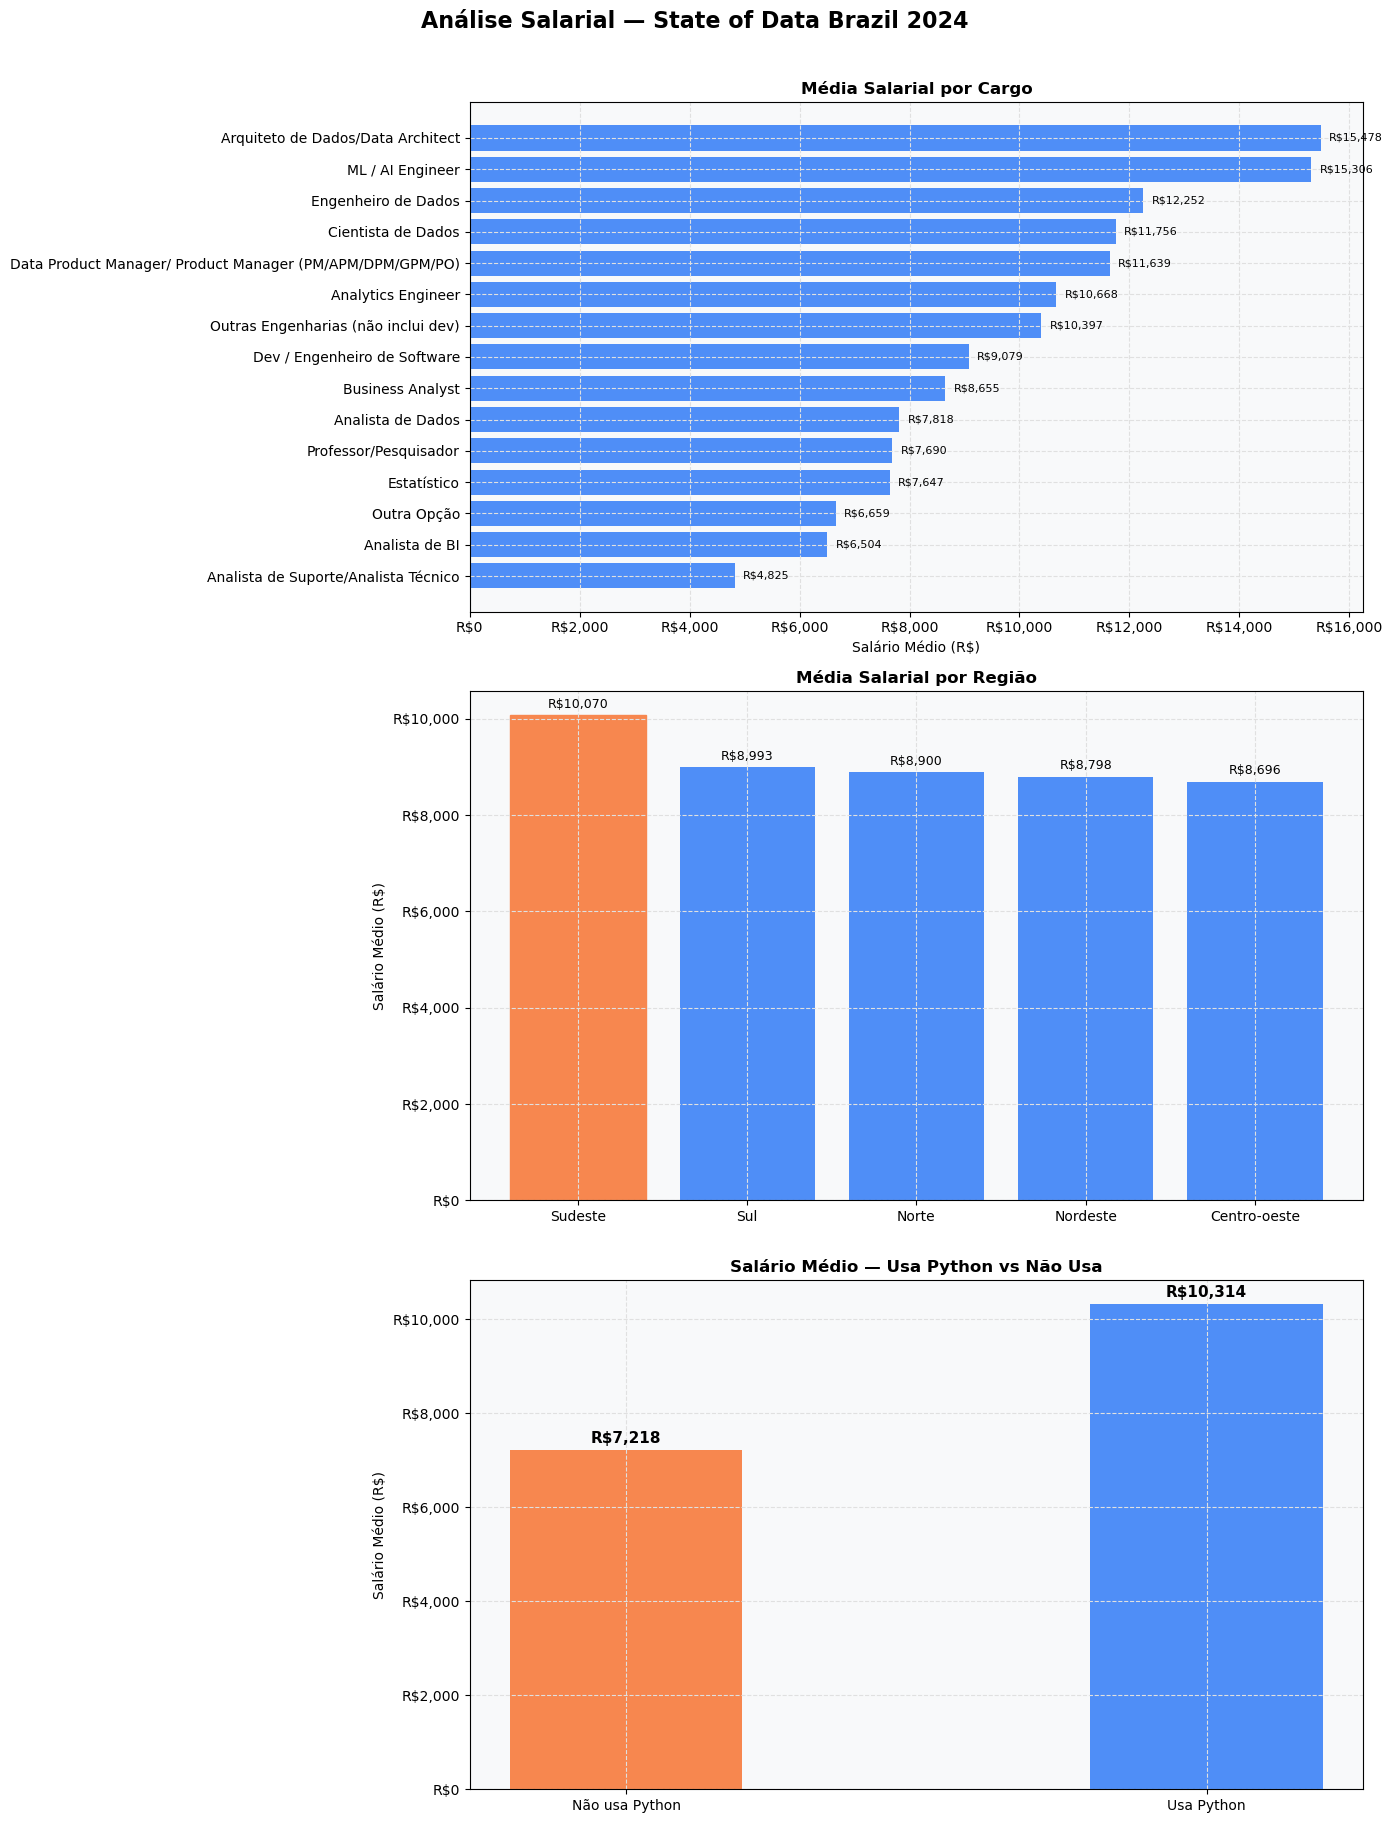

In [12]:
fmt_reais = mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}')

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.suptitle('Análise Salarial — State of Data Brazil 2024', fontsize=16, fontweight='bold', y=1.01)

# --- Cargo ---
media_cargo = df_plot.groupby('cargo_label')['salario_mid'].mean().sort_values()
axes[0].barh(media_cargo.index, media_cargo.values, color=COR_PRINCIPAL)
axes[0].set_title('Média Salarial por Cargo', fontweight='bold')
axes[0].set_xlabel('Salário Médio (R$)')
axes[0].xaxis.set_major_formatter(fmt_reais)
for i, v in enumerate(media_cargo.values):
    axes[0].text(v + 150, i, f'R${v:,.0f}', va='center', fontsize=8)

# --- Região ---
media_regiao = df_plot.groupby('regiao')['salario_mid'].mean().sort_values(ascending=False)
bars = axes[1].bar(media_regiao.index, media_regiao.values, color=COR_PRINCIPAL)
bars[0].set_color(COR_DESTAQUE)
axes[1].set_title('Média Salarial por Região', fontweight='bold')
axes[1].set_ylabel('Salário Médio (R$)')
axes[1].yaxis.set_major_formatter(fmt_reais)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'R${bar.get_height():,.0f}', ha='center', fontsize=9)

# --- Python ---
media_python = (
    df_plot.groupby('usa_python')['salario_mid']
    .mean()
    .rename({0.0: 'Não usa Python', 1.0: 'Usa Python'})
)
bars2 = axes[2].bar(media_python.index, media_python.values,
                    color=[COR_DESTAQUE, COR_PRINCIPAL], width=0.4)
axes[2].set_title('Salário Médio — Usa Python vs Não Usa', fontweight='bold')
axes[2].set_ylabel('Salário Médio (R$)')
axes[2].yaxis.set_major_formatter(fmt_reais)
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'R${bar.get_height():,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('analise_salarial.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Progressão salarial por senioridade

Júnior, Pleno e Sênior em ordem de carreira.

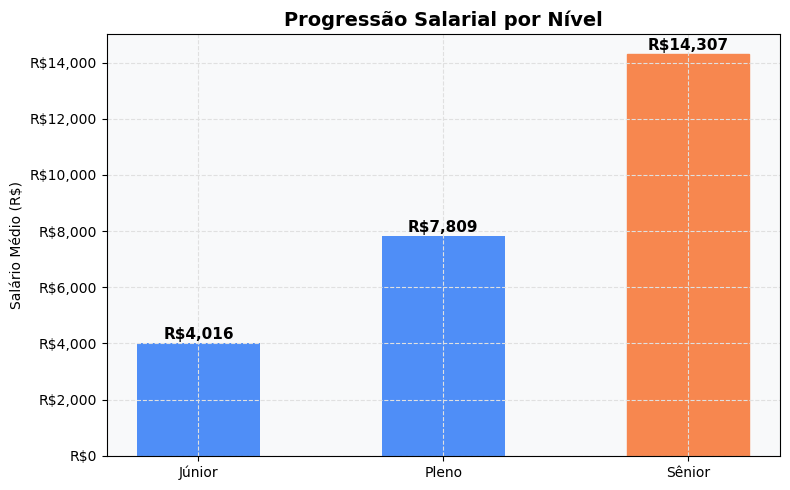

Sênior ganha em média 3.6x mais do que Júnior.


In [13]:
df_nivel = df_plot[df_plot['nivel'] != 'Não informado']
ORDEM_NIVEL = ['Júnior', 'Pleno', 'Sênior']
media_nivel = df_nivel.groupby('nivel')['salario_mid'].mean().reindex(ORDEM_NIVEL)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(media_nivel.index, media_nivel.values, color=COR_PRINCIPAL, width=0.5)
bars[2].set_color(COR_DESTAQUE)
ax.set_title('Progressão Salarial por Nível', fontsize=14, fontweight='bold')
ax.set_ylabel('Salário Médio (R$)')
ax.yaxis.set_major_formatter(fmt_reais)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
            f'R${bar.get_height():,.0f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('salario_por_nivel.png', dpi=150, bbox_inches='tight')
plt.show()

# Multiplicador sênior vs júnior
mult = media_nivel['Sênior'] / media_nivel['Júnior']
print(f"Sênior ganha em média {mult:.1f}x mais do que Júnior.")

## 5. Stack Tecnológica

### 5.1 Ferramentas mais utilizadas no mercado

Proporção de profissionais que declararam usar cada ferramenta.

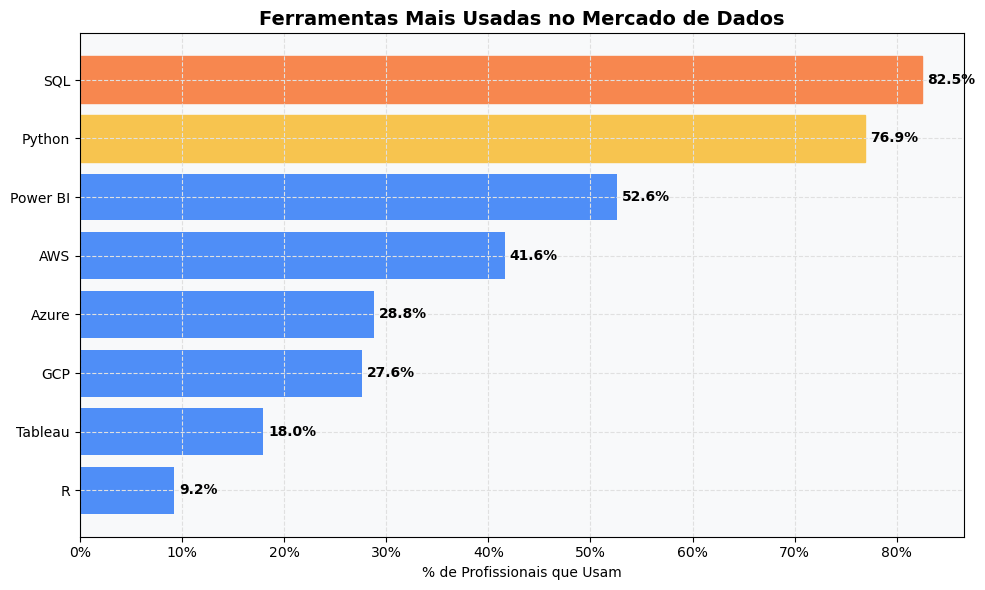

In [14]:
FERRAMENTAS = {
    'SQL':      'usa_sql',
    'Python':   'usa_python',
    'Power BI': 'usa_powerbi',
    'AWS':      'aws',
    'Azure':    'azure',
    'R':        'usa_r',
    'GCP':      'gcp',
    'Tableau':  'tableau',
}

total = len(df_plot)
uso = {nome: df_plot[col].sum() / total * 100 for nome, col in FERRAMENTAS.items()}
uso_ord = dict(sorted(uso.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(uso_ord.keys()), list(uso_ord.values()), color=COR_PRINCIPAL)
bars[0].set_color(COR_DESTAQUE)
bars[1].set_color(COR_AMARELO)
ax.set_title('Ferramentas Mais Usadas no Mercado de Dados', fontsize=14, fontweight='bold')
ax.set_xlabel('% de Profissionais que Usam')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.invert_yaxis()
for i, (_, val) in enumerate(uso_ord.items()):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('ferramentas_mais_usadas.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Stack por cargo

Cada cargo tem um perfil de ferramentas distinto. Este gráfico mostra o percentual  
de uso de cada tecnologia dentro dos cinco cargos mais representativos da amostra.

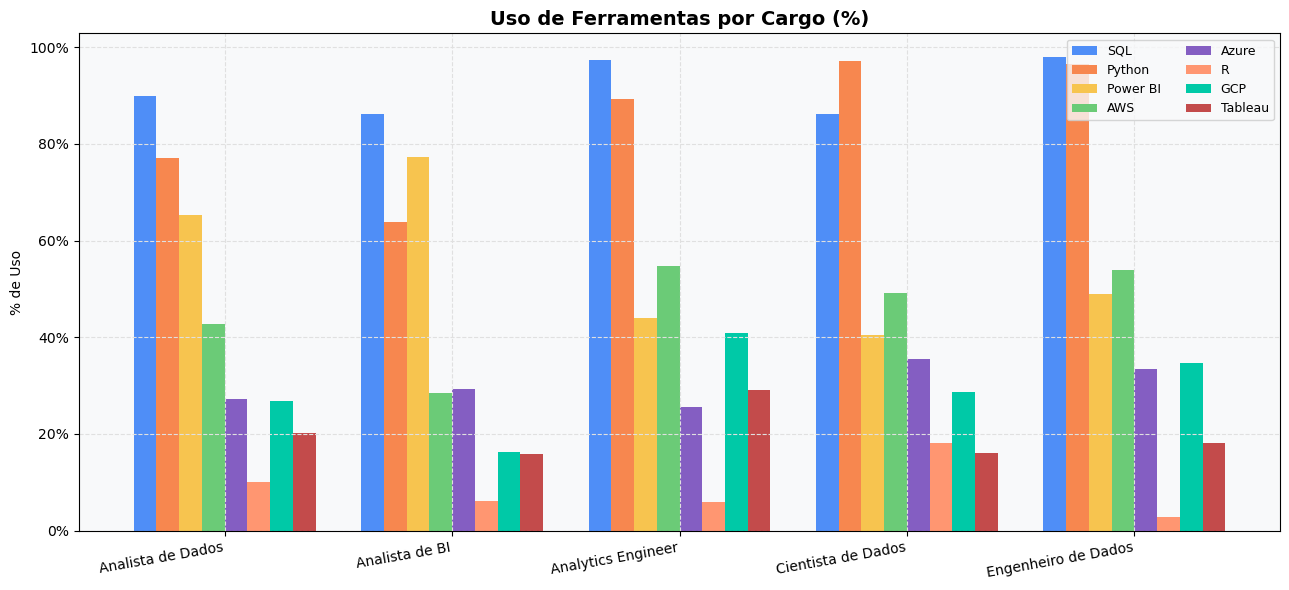

In [15]:
CARGOS_PRINCIPAIS = [
    'Analista de Dados', 'Analista de BI', 'Analytics Engineer',
    'Cientista de Dados', 'Engenheiro de Dados',
]

df_cargo = df_plot[df_plot['cargo_label'].isin(CARGOS_PRINCIPAIS)].copy()

# Matriz: cargo x ferramenta (% de uso)
matriz = pd.DataFrame({
    nome: df_cargo.groupby('cargo_label')[col].mean() * 100
    for nome, col in FERRAMENTAS.items()
}).loc[CARGOS_PRINCIPAIS]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(CARGOS_PRINCIPAIS))
n = len(FERRAMENTAS)
largura = 0.10
cores = [COR_PRINCIPAL, COR_DESTAQUE, COR_AMARELO,
         '#6BCB77', '#845EC2', '#FF9671', '#00C9A7', '#C34B4B']

for i, (nome, cor) in enumerate(zip(FERRAMENTAS.keys(), cores)):
    offset = (i - n / 2) * largura + largura / 2
    bars = ax.bar(x + offset, matriz[nome], largura, label=nome, color=cor)

ax.set_title('Uso de Ferramentas por Cargo (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('% de Uso')
ax.set_xticks(x)
ax.set_xticklabels(CARGOS_PRINCIPAIS, rotation=10, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('stack_por_cargo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Perfil dos Profissionais

Distribuição de cargos e formação acadêmica na amostra.

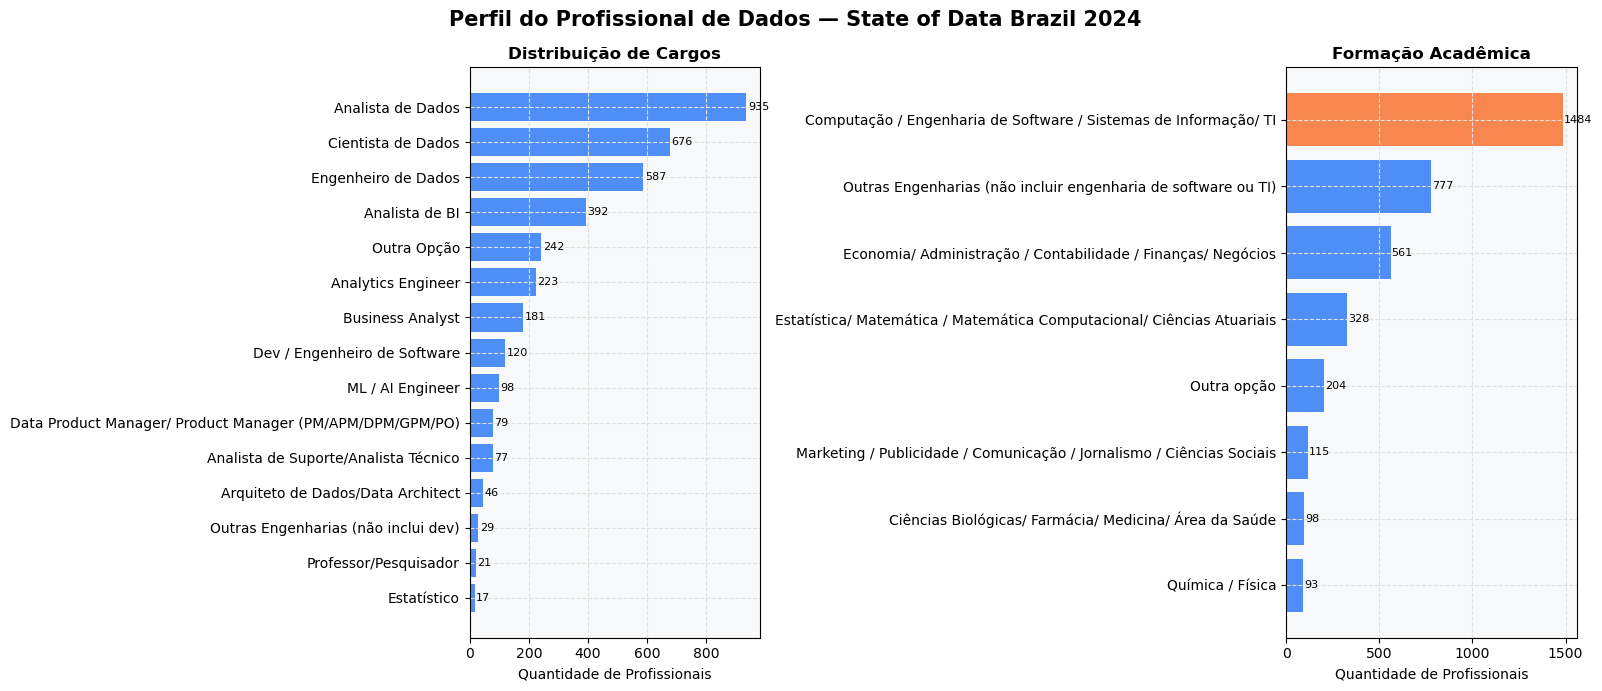

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Perfil do Profissional de Dados — State of Data Brazil 2024',
             fontsize=15, fontweight='bold')

# Cargos
contagem_cargo = df_plot['cargo_label'].value_counts().sort_values()
axes[0].barh(contagem_cargo.index, contagem_cargo.values, color=COR_PRINCIPAL)
axes[0].set_title('Distribuição de Cargos', fontweight='bold')
axes[0].set_xlabel('Quantidade de Profissionais')
for i, v in enumerate(contagem_cargo.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=8)

# Formação
df_form = df_plot[df_plot['formacao'] != 'Não informado']
contagem_form = df_form['formacao'].value_counts().sort_values()
cores_form = [COR_DESTAQUE if i == len(contagem_form) - 1 else COR_PRINCIPAL
              for i in range(len(contagem_form))]
axes[1].barh(contagem_form.index, contagem_form.values, color=cores_form)
axes[1].set_title('Formação Acadêmica', fontweight='bold')
axes[1].set_xlabel('Quantidade de Profissionais')
for i, v in enumerate(contagem_form.values):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('perfil_profissional.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Experiência e Salário

### 7.1 Salário médio por tempo de experiência em dados



C:\Users\tales\AppData\Local\Temp\ipykernel_12016\1019266324.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ORDEM_EXP, rotation=15, ha='right')


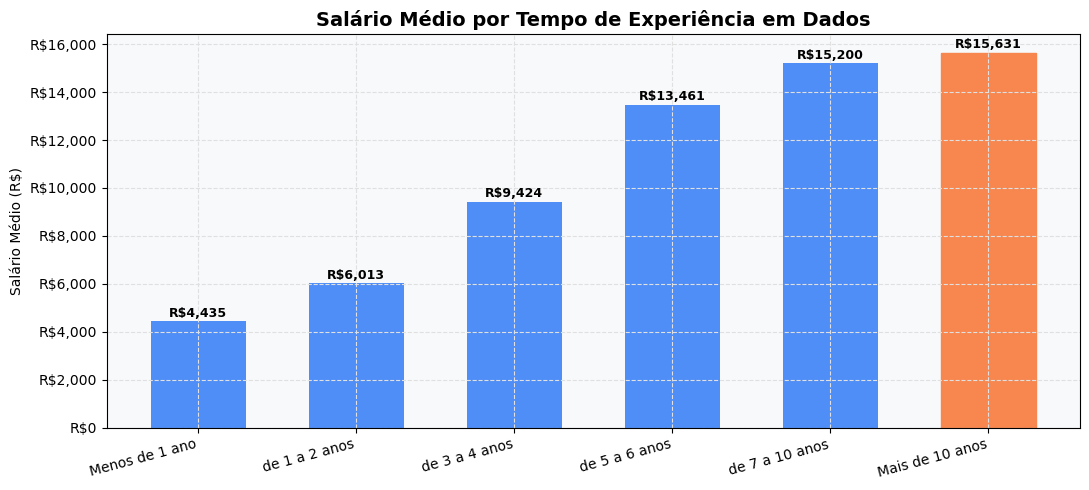

In [17]:
ORDEM_EXP = [
    'Menos de 1 ano',
    'de 1 a 2 anos',
    'de 3 a 4 anos',
    'de 5 a 6 anos',
    'de 7 a 10 anos',
    'Mais de 10 anos',
]

df_exp = df_plot[df_plot['exp_dados'].isin(ORDEM_EXP)]
media_exp = df_exp.groupby('exp_dados')['salario_mid'].mean().reindex(ORDEM_EXP)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(media_exp.index, media_exp.values, color=COR_PRINCIPAL, width=0.6)
bars[-1].set_color(COR_DESTAQUE)
ax.set_title('Salário Médio por Tempo de Experiência em Dados', fontsize=14, fontweight='bold')
ax.set_ylabel('Salário Médio (R$)')
ax.yaxis.set_major_formatter(fmt_reais)
ax.set_xticklabels(ORDEM_EXP, rotation=15, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'R${bar.get_height():,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('salario_por_experiencia.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Distribuição salarial — nível dentro de cada cargo

Júnior, Pleno e Sênior nos cinco cargos principais.  
Permite comparar não só o nível médio, mas também a variação interna de cada função.

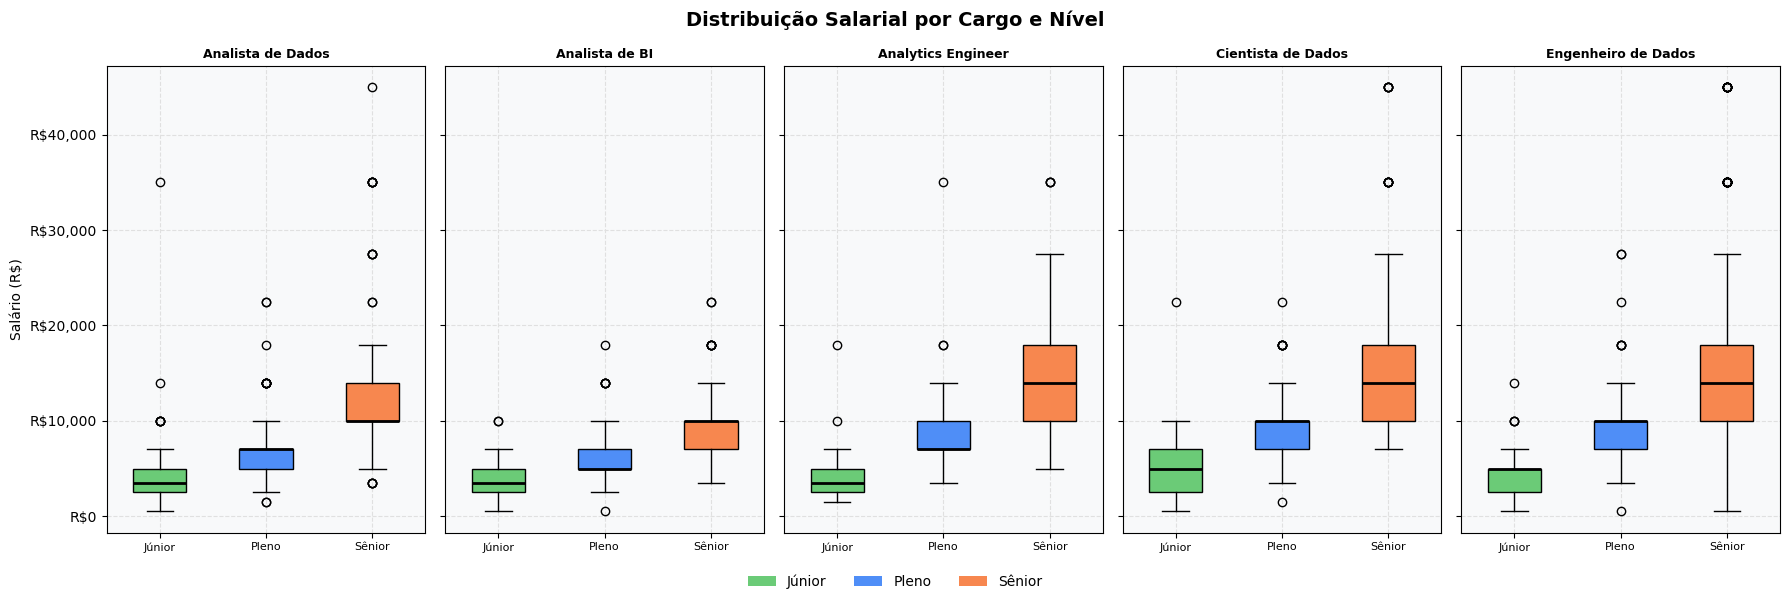

In [18]:
df_box = df_plot[
    df_plot['cargo_label'].isin(CARGOS_PRINCIPAIS) &
    (df_plot['nivel'].isin(['Júnior', 'Pleno', 'Sênior']))
].copy()

cores_nivel = {'Júnior': '#6BCB77', 'Pleno': COR_PRINCIPAL, 'Sênior': COR_DESTAQUE}

fig, axes = plt.subplots(1, len(CARGOS_PRINCIPAIS), figsize=(18, 6), sharey=True)
fig.suptitle('Distribuição Salarial por Cargo e Nível', fontsize=14, fontweight='bold')

for ax, cargo in zip(axes, CARGOS_PRINCIPAIS):
    dados = [
        df_box[(df_box['cargo_label'] == cargo) & (df_box['nivel'] == nivel)]['salario_mid'].dropna()
        for nivel in ['Júnior', 'Pleno', 'Sênior']
    ]
    bp = ax.boxplot(dados, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, nivel in zip(bp['boxes'], ['Júnior', 'Pleno', 'Sênior']):
        patch.set_facecolor(cores_nivel[nivel])
    ax.set_title(cargo, fontsize=9, fontweight='bold')
    ax.set_xticklabels(['Júnior', 'Pleno', 'Sênior'], fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('Salário (R$)')
        ax.yaxis.set_major_formatter(fmt_reais)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cor, label=nivel) for nivel, cor in cores_nivel.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('salario_nivel_cargo.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Exportação do Dataset Limpo

In [19]:
OUTPUT_PATH = Path('../data/output/output_final.csv')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset exportado: {OUTPUT_PATH}")
print(f"Shape: {df.shape}")

Dataset exportado: ..\data\output\output_final.csv
Shape: (5078, 23)
